# Step 2a — Constant-theta filter

Turn the raw walk trajectories from `02_semantic_walk.ipynb` into training sentences by applying a **single fixed threshold** `theta = 0.70` (the converged baseline value). For each raw walk we rebuild `sentence = [anchor] + [every raw_path[i+1] whose raw_sims[i] >= theta]`, then keep only sentences with at least `min_sentence_length` products.

`theta` decides only what gets **logged**, never where the walk went — the walk already happened upstream. Because every filter notebook reads the same `walk_raw_paths.jsonl`, all threshold methods are compared on identical trajectories.

**Inputs** (from `02_semantic_walk.ipynb`, in `outputs/`)
- `walk_raw_paths.jsonl` — raw walks (`anchor_id`, `raw_path`, `raw_sims`, `hops_taken`)
- `walk_config.json` — the walk run this filter is built on (for traceability)
- `product_basket_freq.json` — per-product basket counts for the popularity check

Also loads Step 1's `embeddings.npy` + `product_id_to_index.json` (rank novelty test) and `products_text.csv` (product names).

**Outputs** (to `outputs/`)
- `filters/constant_theta/theta_0.70/walk_sentences.jsonl` — one kept sentence per line
- `filters/constant_theta/theta_0.70/filter_config.json` — method, theta, min length, timestamp, and the source walk timestamp

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters

This method applies one constant threshold to every hop of every walk. `theta` is the converged baseline value; `min_sentence_length` drops sentences that carry no signal (anchor only).

In [2]:
METHOD_NAME = "constant_theta"
VALUE_LABEL = "theta_0.70"
FILTER_DIR = OUT_DIR / "filters" / METHOD_NAME / VALUE_LABEL
FILTER_DIR.mkdir(parents=True, exist_ok=True)
theta = 0.70               # log a winner iff its raw sim to the anchor >= theta
min_sentence_length = 2    # discard sentences shorter than this

# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Everything this notebook needs was produced upstream: the raw walks and walk config from `02_semantic_walk.ipynb`, the per-product basket counts (so the popularity check never rebuilds the basket graph), and Step 1's embeddings + id map for the rank novelty test.

In [3]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for the rank novelty test,
# and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Apply the constant-theta filter

For each raw walk, rebuild the sentence: start with the anchor, then append every subsequent product whose recorded similarity to the anchor cleared `theta`. Since `raw_sims[i]` is the similarity for `raw_path[i + 1]`, this is a direct zip of `raw_path[1:]` against `raw_sims`. Keep only sentences with `>= min_sentence_length` products.

In [4]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


filtered = []          # {"anchor_id", "raw_path", "sentence", "hops_taken"} for every walk
kept_sentences = []    # {"anchor_id", "sentence"} for the kept ones only
n_total = 0
n_discarded = 0

for w in raw_walks:
    n_total += 1
    sentence = filter_walk(w, theta)
    filtered.append({
        "anchor_id": w["anchor_id"],
        "raw_path": w["raw_path"],
        "sentence": sentence,
        "hops_taken": w["hops_taken"],
    })
    if len(sentence) >= min_sentence_length:
        kept_sentences.append({"anchor_id": w["anchor_id"], "sentence": sentence})
    else:
        n_discarded += 1

print(f"walks processed  : {n_total:,}")
print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,} ({100 * n_discarded / max(n_total, 1):.1f}%)")

walks processed  : 400,100
sentences kept   : 131,000
discarded (short): 269,100 (67.3%)


## 5. Save outputs

The kept sentences plus a filter-config sidecar. `filters/constant_theta/theta_0.70/filter_config.json` records the method, its parameters, and the timestamp of the `walk_config.json` this corpus was built from — so a sentence file is always traceable back to both the filter run and the walk run behind it.

In [5]:
# 1) Kept sentences.
sent_path = FILTER_DIR / "walk_sentences.jsonl"
with open(sent_path, "w") as f:
    for s in kept_sentences:
        f.write(json.dumps(s) + "\n")

# 2) Filter configuration (+ provenance back to the walk run).
filter_config = {
    "method": METHOD_NAME,
    "theta": theta,
    "min_sentence_length": min_sentence_length,
    "n_raw_walks": n_total,
    "n_sentences_kept": len(kept_sentences),
    "source_walk_config_timestamp": walk_config.get("timestamp"),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
}
cfg_path = FILTER_DIR / "filter_config.json"
with open(cfg_path, "w") as f:
    json.dump(filter_config, f, indent=2)

print("Saved", sent_path.name, "and", cfg_path.name)
print(json.dumps(filter_config, indent=2))

Saved walk_sentences__constant_theta.jsonl and filter_config__constant_theta.json
{
  "method": "constant_theta",
  "theta": 0.7,
  "min_sentence_length": 2,
  "n_raw_walks": 400100,
  "n_sentences_kept": 131000,
  "source_walk_config_timestamp": "2026-08-08T14:06:21",
  "timestamp": "2026-08-08T15:34:33"
}


## 6. Validation — sentence lengths and discard rate

The filter-dependent checks: how long the kept sentences are, and what fraction of raw walks were discarded for falling short of `min_sentence_length`.

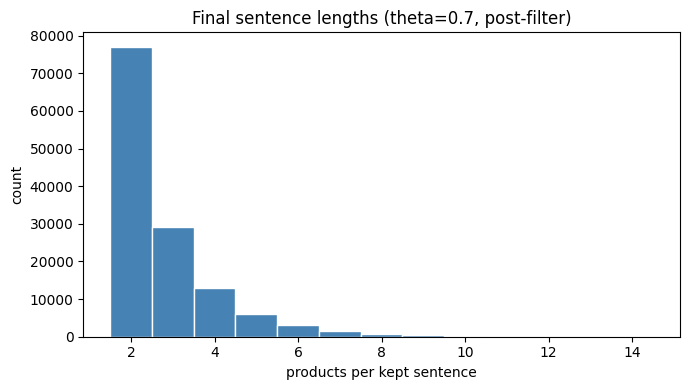

sentences kept   : 131,000
discarded (short): 269,100/400,100 (67.3%)
sentence length mean/median/max: 2.78 / 2 / 14


In [6]:
sent_lengths = [len(s["sentence"]) for s in kept_sentences]

fig, ax = plt.subplots(figsize=(7, 4))
if sent_lengths:
    ax.hist(sent_lengths, bins=range(min_sentence_length, max(sent_lengths) + 2),
            align="left", color="steelblue", edgecolor="white")
ax.set_title(f"Final sentence lengths (theta={theta}, post-filter)")
ax.set_xlabel("products per kept sentence"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,}/{n_total:,} "
      f"({100 * n_discarded / max(n_total, 1):.1f}%)")
if sent_lengths:
    print(f"sentence length mean/median/max: "
          f"{np.mean(sent_lengths):.2f} / {int(np.median(sent_lengths))} / {max(sent_lengths)}")

### Example walks

A handful of full walks for manual inspection: anchor, the raw path (every bridge the walk crossed), and the sentence the filter kept from it.

In [7]:
kept_filtered = [x for x in filtered if len(x["sentence"]) >= min_sentence_length]
display_rng = np.random.default_rng(0)
picks = (display_rng.choice(len(kept_filtered),
                            size=min(10, len(kept_filtered)), replace=False)
         if kept_filtered else [])

for i in picks:
    x = kept_filtered[int(i)]
    print("anchor   :", name(x["anchor_id"]))
    print("raw path :", " -> ".join(names(x["raw_path"])))
    print("sentence :", " -> ".join(names(x["sentence"])))
    print("hops     :", x["hops_taken"])
    print("-" * 90)

anchor   : No Calories No Caffeine Seltzer Water
raw path : No Calories No Caffeine Seltzer Water -> Original Jellybeans -> Roasted Garlic Hummus -> Shredded Gouda -> Strawberries -> Zero Calorie Cola -> Soda -> Spring Water -> 100% Raw Coconut Water -> Michigan Organic Kale -> Sweet Onion -> Four Cheese Thin Crust Pizza -> Slices Cheddar Cheese -> Raspberry Lemonade -> Chocolate Coconut Almond Milk -> Organic American Cheese Singles
sentence : No Calories No Caffeine Seltzer Water -> Zero Calorie Cola
hops     : 15
------------------------------------------------------------------------------------------
anchor   : Strawberries
raw path : Strawberries -> Organic AppleApple -> Banana -> Organic Grape Tomatoes -> Organic Red Cabbage -> Organic Strawberries -> Frozen Organic Wild Blueberries -> Organic Cucumber -> Limes -> White Onion -> Squeeze Tomato Ketchup -> Cranberry Juice -> Variety Pack Snack Stacks -> Spring Mix -> Blackberries -> Coffee Ice Cream
sentence : Strawberries -> Bana

## 7. Rank novelty — does the filter surface *new* substitutes?

For each stress-test anchor, look at every product its kept sentences surfaced and find where that product sits in Step 1's own full similarity ranking for the anchor (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new" — the walk + filter earns its keep only when it surfaces genuine substitutes ranked *far down* that list.

In [8]:
surfaced = {pid: Counter() for pid in STRESS_TEST_IDS}
for s in kept_sentences:
    a = s["anchor_id"]
    if a in surfaced:
        for p in s["sentence"]:
            if p != a:
                surfaced[a][p] += 1

# Compute each anchor's full similarity vector + rank lookup ONCE, then reuse it
# across all of that anchor's surfaced targets (instead of re-ranking per target).
print("Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?")
print("=" * 70)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"\n{nm} ({pid}) — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]        # cosine vs anchor (unit-norm)
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))        # rank[idx]: 0 = anchor, 1 = #1 neighbour
    print(f"\n{nm} ({pid})")
    surfaced_here = surfaced.get(pid, Counter())
    if not surfaced_here:
        print("  (no substitutes surfaced)")
    for p, c in surfaced_here.most_common():
        idx = pid_to_idx[p]
        rank = int(ranks[idx])
        flag = "  <- inside Step 1's own top-10, not new" if rank <= 10 else ""
        print(f"  {c}x  {name(p):<45} rank={rank:>6}  sim={sims[idx]:.3f}{flag}")

Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?

Whole Milk (4210)
  8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's own top-10, not new
  5x  Half & Half                                   rank=    57  sim=0.805
  4x  Organic Fat Free Milk                         rank=   170  sim=0.765
  4x  Organic Reduced Fat 2% Milk                   rank=   598  sim=0.710
  3x  Unsweetened Almondmilk                        rank=   454  sim=0.723
  3x  Organic Milk                                  rank=    22  sim=0.834
  3x  Unsweetened Vanilla Almond Milk               rank=   356  sim=0.735
  3x  Organic Chocolate 1% Milk with DHA Omega-3    rank=   583  sim=0.712
  3x  Salted Butter                                 rank=   637  sim=0.706
  3x  Fat Free Milk                                 rank=    29  sim=0.825
  2x  Unsweetened Almond Milk                       rank=   351  sim=0.736
  2x  Vitamin D Organic Whole Milk     

## 8. Background popularity check

How common is each surfaced product overall? A "substitute" that appears in a huge fraction of baskets may just be popular rather than genuinely related. We read the per-product basket counts straight from `product_basket_freq.json` — no basket graph to rebuild.

In [9]:
print("Background popularity check: how common is each surfaced product overall?")
print("=" * 70)

for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor itself appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for p, c in surfaced.get(pid, Counter()).most_common(10):
        bg_freq = product_basket_count.get(p, 0)
        bg_pct = 100 * bg_freq / total_baskets if total_baskets else 0
        print(f"  {c}x found   {name(p):<40} appears in "
              f"{bg_freq:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity check: how common is each surfaced product overall?

Whole Milk (4210) — anchor itself appears in 11,103 / 1,000,000 baskets (1.1%)
  8x found   Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  5x found   Half & Half                              appears in  21,533 / 1,000,000 baskets (2.2%)
  4x found   Organic Fat Free Milk                    appears in   8,216 / 1,000,000 baskets (0.8%)
  4x found   Organic Reduced Fat 2% Milk              appears in  14,910 / 1,000,000 baskets (1.5%)
  3x found   Unsweetened Almondmilk                   appears in  15,486 / 1,000,000 baskets (1.5%)
  3x found   Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
  3x found   Unsweetened Vanilla Almond Milk          appears in   8,141 / 1,000,000 baskets (0.8%)
  3x found   Organic Chocolate 1% Milk with DHA Omega-3 appears in   1,046 / 1,000,000 baskets (0.1%)
  3x found   Salted Butter                  

---
## 8. Transform filtered walks into human-readable format

In [10]:
readable_path = FILTER_DIR / "walk_sentences_readable.txt"
prev_anchor = None
with open(readable_path, "w") as f:
    for s in kept_sentences:
        if s["anchor_id"] != prev_anchor:
            if prev_anchor is not None:
                f.write("\n")
            prev_anchor = s["anchor_id"]
        f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

print(f"Saved {readable_path.name} ({len(kept_sentences):,} lines across "
      f"{len({s['anchor_id'] for s in kept_sentences}):,} anchors)")

Saved walk_sentences__constant_theta_readable.txt (131,000 lines across 16,470 anchors)
